# GAN 관련 개념 정리

## 1. GAN (Generative Adversarial Network)
- **정의**: 생성적 적대 신경망. 데이터의 분포를 학습하여 새로운 샘플을 생성하는 모델.
- **구성**
  - **Generator(생성기)**: 랜덤 노이즈(z)를 입력으로 받아 진짜처럼 보이는 가짜 데이터를 생성
  - **Discriminator(판별기)**: 입력 데이터가 진짜(real)인지 가짜(fake)인지 구별
- **학습 구조**: 두 모델이 **적대적(adversarial) 학습**으로 동시에 학습  
  - 생성기는 판별기를 속이도록 학습
  - 판별기는 생성기의 가짜를 잘 구별하도록 학습
- **핵심 수식**
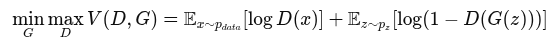
  - GAN의 목표: Discriminator는 진짜 데이터 x에 대해 D(x)를 최대화, 가짜 데이터 G(z)에 대해 D(G(z))를 최소화
  - Generator는 D(G(z))를 최대화하여 판별기를 속임
- **장점**: 데이터의 복잡한 분포를 학습 가능, 현실적인 샘플 생성
- **단점**: 학습 불안정, 모드 붕괴(mode collapse) 발생 가능

---

## 2. DCGAN (Deep Convolutional GAN)
- **특징**: CNN 구조 차용, fully connected layer 최소화
- **구성**
  - Generator: Transposed Convolution(ConvTranspose2d) 기반으로 이미지 생성
  - Discriminator: Convolution + BatchNorm + LeakyReLU
- **장점**: 고해상도 이미지 생성 가능, 학습 안정성 향상
- **권장 구조**
  - BatchNorm 사용으로 학습 안정화
  - Activation: Generator → ReLU, Discriminator → LeakyReLU
  - Fully connected layer 최소화

---

## 3. pix2pix GAN (Conditional GAN)
- **용도**: 이미지 변환(Image-to-Image Translation)
  - 예: 흑백 → 컬러, 스케치 → 사진, 위성사진 → 지도
- **생성기 구조**: **U-Net 기반 Encoder-Decoder**
  - **Encoder (Downsampling)**
    - 이미지 압축, 특징 추출
    - 각 계층: Conv2d → BatchNorm → LeakyReLU
  - **Decoder (Upsampling)**
    - 업샘플링 후 Conv2d
    - **Skip Connection**으로 encoder 출력과 연결 → 세밀한 구조 유지
    - Activation: ReLU, 최종 tanh
- **Discriminator**: PatchGAN 사용
  - 이미지를 작은 패치 단위로 판단 → 세밀한 로컬 구조 학습 가능
- **특징**: 조건부 GAN(Conditional GAN)  
  → 입력 이미지 조건을 활용하여 대응 이미지 생성

---

## 4. VAE (Variational Autoencoder)
- **정의**: 입력 데이터를 latent space에 인코딩하고 다시 디코딩하는 **확률적 generative model**
- **구조**: Encoder → Latent space → Decoder
- **차이점**: 일반 Autoencoder가 단순히 입력 재구성만 하는 것과 달리
  - latent space를 **확률분포(평균, 분산)**로 모델링
  - 학습 시 KL divergence로 latent 분포를 정규화
- **장점**
  1. **확률적 샘플링 가능** → 다양한 데이터 생성 가능
  2. **Gradient 계산 가능** → end-to-end 학습 용이
- **활용 사례**: 이미지 생성, 이상치 탐지, 데이터 압축

---

## 추가 보충
- **GAN vs VAE 차이점**
  | 항목 | GAN | VAE |
  |------|-----|-----|
  | 학습 방식 | 적대적 학습 | 재구성 + KL divergence |
  | 출력 특성 | 선명하고 사실적 | 다소 흐릿하지만 확률적 다양성 |
  | 장점 | 현실적인 샘플 | 안정적인 학습, 확률적 표현 |
- **Conditional GAN(CGAN)**
  - 특정 조건(라벨, 이미지)을 입력으로 받아 조건부 샘플 생성
  - pix2pix, CycleGAN 등이 대표적 예
